# Système Intelligent de Filtrage des Emails pour la Sécurité des Communications #

**Chargement des donnees et Importation des bibliotheque**

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import re
from wordcloud import WordCloud

import nltk
from nltk.tokenize import wordpunct_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import joblib


In [2]:
#df=pd.read_csv(r'C:\Users\saido\Desktop\Simplon\Brief3\EmailAimodel\DataSet_Emails.csv')
df= pd.read_csv('DataSet_Emails.csv')
df.head()

,Unnamed: 0,message_id,text,label,label_text,subject,message,date
0,0,33214,any software just for 15 $ - 99 $ understandin...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,1,11929,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,2,19784,wanted to try ci 4 lis but thought it was way ...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,3,2209,"enron / hpl actuals for december 11 , 2000 tec...",0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,4,15880,looking for cheap high - quality software ? ro...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13


Afficher les informations de chaque columms 

In [3]:
df.info()
print('la taille des donnes',df.shape)
print('le nombre de columns est :',df.shape[1],'le nombre des ligne',df.shape[0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31716 entries, 0 to 31715
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  31716 non-null  int64 
 1   message_id  31716 non-null  int64 
 2   text        31665 non-null  object
 3   label       31716 non-null  int64 
 4   label_text  31716 non-null  object
 5   subject     31442 non-null  object
 6   message     31371 non-null  object
 7   date        31716 non-null  object
dtypes: int64(3), object(5)
memory usage: 1.9+ MB
la taille des donnes (31716, 8)
le nombre de columns est : 8 le nombre des ligne 31716


Le DataFrame contient 31716 lignes et 8 colonnes.

Les colonnes sont de types int64 (3 colonnes) et object (5 colonnes).

Certaines colonnes ont des valeurs manquantes :

text : 51 valeurs manquantes

subject : 274 valeurs manquantes

message : 345 valeurs manquantes

La mémoire utilisée est d’environ 1.9 Mo.

Les colonnes Unnamed: 0 et message_id semblent être des identifiants.

# Gestion des valeurs manquantes #

In [4]:
df.isnull().sum()

Unnamed: 0      0
message_id      0
text           51
label           0
label_text      0
subject       274
message       345
date            0
dtype: int64

Le DataFrame contient :

51 lignes où la colonne text est vide ou NaN

274 lignes où subject est vide

345 lignes où message est vide

In [5]:
#  Supprimer les lignes où la colonne 'text' est vide ou manquante
df = df.dropna(subset=['text'])  

In [6]:
df.isnull().sum()

Unnamed: 0      0
message_id      0
text            0
label           0
label_text      0
subject       223
message       294
date            0
dtype: int64

Toutes les valeurs manquantes ont été supprimées avec succès dans les colonnes ciblées :
Il ne reste plus aucune ligne avec NaN dans 'text', 'subject', ou 'message'.



In [7]:
df.duplicated().sum()

np.int64(0)

Il n'y a aucune ligne dupliquée dans ton DataFrame

In [8]:
df = df[df['text'].str.strip() != '']        # supprime les chaînes vides (" ")

#  Convertir tout le texte en minuscules
df['text'] = df['text'].str.lower()

df.head()

,Unnamed: 0,message_id,text,label,label_text,subject,message,date
0,0,33214,any software just for 15 $ - 99 $ understandin...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,1,11929,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,2,19784,wanted to try ci 4 lis but thought it was way ...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,3,2209,"enron / hpl actuals for december 11 , 2000 tec...",0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,4,15880,looking for cheap high - quality software ? ro...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13


1. Suppression des lignes contenant du texte vide
Cette ligne élimine les messages vides ou contenant uniquement des espaces blancs dans la colonne text.

    Cela garantit que chaque ligne a un contenu textuel utile pour l’analyse.

2. Conversion de tout le texte en minuscules
Cette ligne transforme tout le contenu de la colonne text en minuscules.

    Exemple : "Free OFFER Now" devient "free offer now"

La taille de DataSet apres la supprition

In [9]:
print('la taille de dataSet',df.shape)

la taille de dataSet (31665, 8)


**Difference entre colonne message et text**

In [10]:
print(df['text'][0])
print(df['message'][0])

any software just for 15 $ - 99 $ understanding oem software
lead me not into temptation ; i can find the way myself .
# 3533 . the law disregards trifles .
understanding oem software
lead me not into temptation ; i can find the way myself .
# 3533 . the law disregards trifles .


Le jeu de données contient deux colonnes textuelles principales :

text : représente une version résumée ou un extrait du message, souvent utilisée comme aperçu ou titre. Ce champ est plus court et peut contenir des mots-clés ou une synthèse.

message : contient le contenu complet du message, parfois avec plusieurs lignes, des citations, ou des signatures.

Compter et visualiser la distribution des classes (Spam vs Ham)

In [11]:
counts=df['label_text'].value_counts()
print(counts)

label_text
spam    16112
ham     15553
Name: count, dtype: int64


Il y a 3672 messages étiquetés comme spam

Il y a 2412 messages étiquetés comme **ham

**Suppression des colonnes inutiles**

In [12]:
df=df.drop(['Unnamed: 0','message_id'],axis=1)
df.head()

,text,label,label_text,subject,message,date
0,any software just for 15 $ - 99 $ understandin...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18
1,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19
2,wanted to try ci 4 lis but thought it was way ...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11
3,"enron / hpl actuals for december 11 , 2000 tec...",0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12
4,looking for cheap high - quality software ? ro...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13


Les colonnes Unnamed: 0 et message_id ont été supprimées car elles ne contiennent aucune information utile pour l’analyse. Elles n’apportent aucune valeur ajoutée à la classification spam/ham, ce sont des identifiants ou des index techniques.

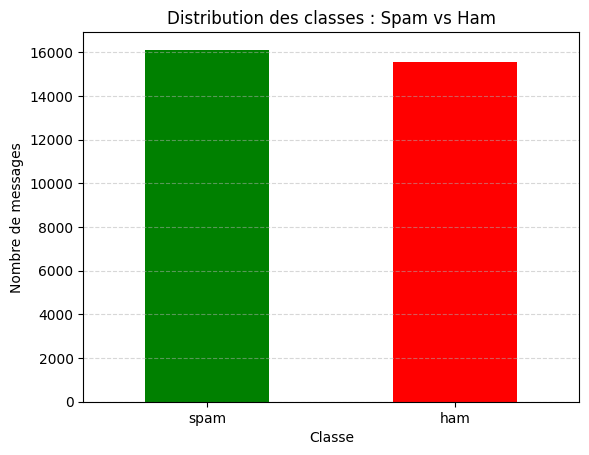

In [13]:
import matplotlib.pyplot as plt

# Affichage sous forme d'histogramme
counts.plot(kind='bar', color=['green', 'red'])

plt.title('Distribution des classes : Spam vs Ham')
plt.xlabel('Classe')
plt.ylabel('Nombre de messages')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


Le graphique en barres montre la répartition des messages entre les classes spam et ham. On observe un déséquilibre, avec une majorité de messages [ adapter : spam ou ham], ce qui peut influencer l’entraînement du modèle.

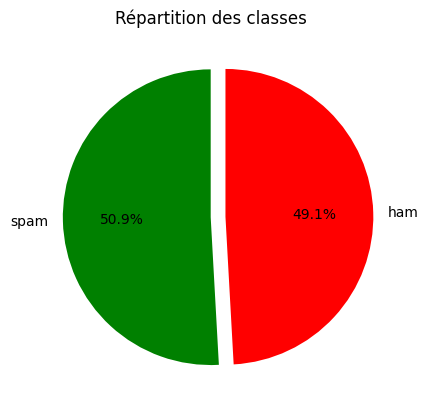

In [14]:
# Camembert
counts.plot(kind='pie', autopct='%1.1f%%', colors=['green', 'red'], startangle=90, explode=(0, 0.1))

plt.title('Répartition des classes')
plt.ylabel('')  # Supprimer le label par défaut
plt.show()


Le graphique en camembert illustre la répartition proportionnelle des messages entre les classes spam et ham. Il permet de visualiser facilement la part relative de chaque classe dans le jeu de données. Cette répartition est importante à considérer pour l’équilibrage du modèle.

Créer des wordclouds pour les spams et les ham

In [15]:
from wordcloud import WordCloud

Séparer les textes Spam et Ham

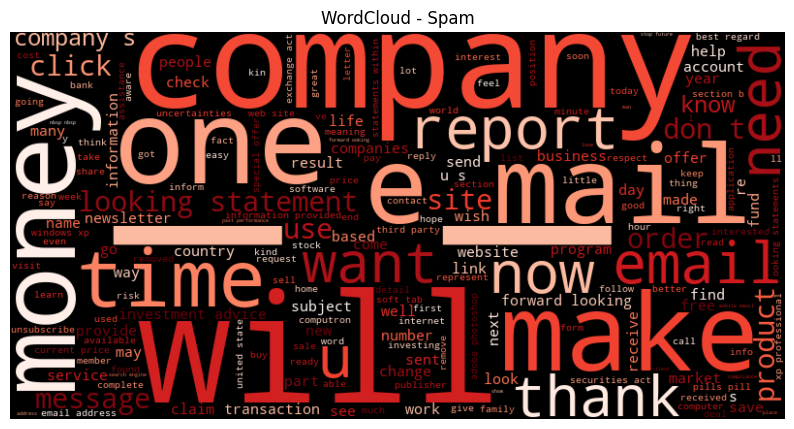

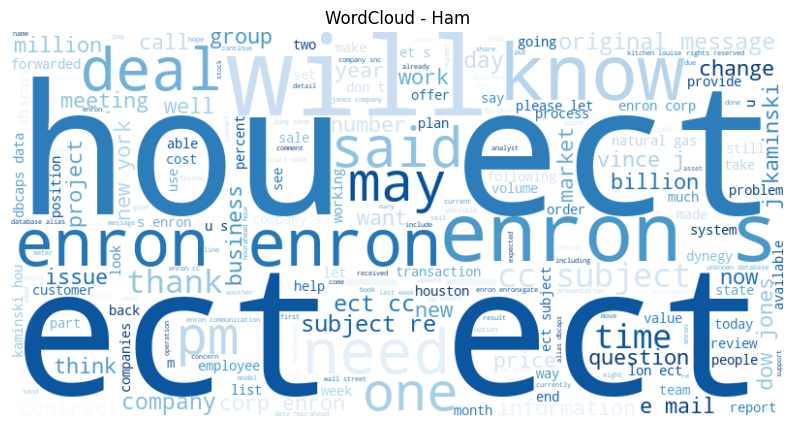

In [16]:
spam_text = " ".join(df[df['label_text'] == "spam"]['text'].astype(str))
ham_text = " ".join(df[df['label_text'] == "ham"]['text'].astype(str))

plt.figure(figsize=(10,6))
wc_spam = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(spam_text)
plt.imshow(wc_spam, interpolation='bilinear'); 
plt.axis("off"); 
plt.title("WordCloud - Spam")
plt.show()

plt.figure(figsize=(10,6))
wc_ham = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(ham_text)
plt.imshow(wc_ham, interpolation='bilinear'); 
plt.axis("off"); 
plt.title("WordCloud - Ham")
plt.show()

Les nuages de mots (WordClouds) permettent de visualiser les termes les plus fréquents dans les messages spam et ham.
Le WordCloud rouge met en évidence les mots typiques des spams, souvent liés à des offres commerciales ou promotions.
Le WordCloud bleu montre les mots courants dans les messages légitimes (ham), généralement plus neutres et conversationnels.
Cette visualisation aide à comprendre les différences lexicales entre les deux classes, utiles pour la construction du modèle.

Longueur moyenne en caractères

In [17]:
# Ajouter une colonne 'length' contenant la longueur de chaque message
df['length'] = df['text'].astype(str).apply(len)

# Longueur moyenne
mean_length = df['length'].mean()
print(f"Longueur moyenne des messages (caractères) : {mean_length:.2f}")


Longueur moyenne des messages (caractères) : 1509.55


Cette statistique permet d’avoir une idée générale de la taille des messages traités. Une longueur moyenne élevée peut indiquer des messages plus détaillés ou complexes, tandis qu’une longueur faible suggère des messages courts, souvent typiques des spams ou notifications. 

**Suppression des ponctuations et des caractères spéciaux**

In [18]:

# Fonction de nettoyage
def nettoyer_ponctuation(text):
    # Supprimer tout sauf les lettres et les espaces
    return re.sub(r'[^a-zA-Z\s]', '', text)

# Appliquer à la colonne 'text'
df['text'] = df['text'].astype(str).apply(nettoyer_ponctuation)
df.head()

,text,label,label_text,subject,message,date,length
0,any software just for understanding oem s...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18,156
1,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19,1112
2,wanted to try ci lis but thought it was way t...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11,242
3,enron hpl actuals for december teco tap ...,0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12,127
4,looking for cheap high quality software rota...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13,329



**Suppression des ponctuations et des caractères spéciaux**

Pour améliorer la qualité des données textuelles, une fonction de nettoyage a été appliquée à la colonne `text`. Cette fonction supprime tous les caractères qui ne sont pas des lettres (a-z, A-Z) ou des espaces, en utilisant une expression régulière. Ainsi, la ponctuation, les chiffres et les caractères spéciaux sont retirés de chaque message.

*Intérêt :*  
Cette étape permet d’obtenir un texte plus homogène et d’éviter que des signes de ponctuation ou des caractères non pertinents n’influencent l’analyse ou la modélisation. Cela simplifie aussi le travail des algorithmes de traitement du langage naturel, qui se concentrent alors uniquement sur les mots porteurs de sens.


Suppression des stopwords (nltk)

Supprimer les stopwords de la colonne text

In [19]:

# Télécharger les ressources nécessaires une seule fois
nltk.download('punkt')
nltk.download('stopwords')

# Initialiser les outils
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# 1. Tokenisation
df['tokens'] = df['text'].apply(lambda x: wordpunct_tokenize(x.lower()))

# 2. Suppression des stopwords et des caractères non alphabétiques
df['filtered_tokens'] = df['tokens'].apply(lambda tokens: [t for t in tokens if t.isalpha() and t not in stop_words])

# 3. Stemming
df['stemmed_tokens'] = df['filtered_tokens'].apply(lambda tokens: [stemmer.stem(t) for t in tokens])

# 4. Reconstruction du texte nettoyé
df['clean_text'] = df['stemmed_tokens'].apply(lambda tokens: ' '.join(tokens))


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\saido\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saido\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Suppression des stopwords, tokenisation et stemming**

Pour améliorer la qualité des données textuelles et préparer les messages à l’analyse automatique, plusieurs étapes de prétraitement du texte ont été réalisées :

- **Tokenisation** : Cette étape consiste à découper chaque message en une liste de mots (appelés *tokens*). Cela permet de traiter chaque mot individuellement.
- **Suppression des stopwords** : Les *stopwords* sont des mots très fréquents dans une langue (comme « the », « and », « is » en anglais) mais qui n’apportent pas d’information utile pour la classification. Ils sont retirés pour ne garder que les mots porteurs de sens.
- **Filtrage des caractères non alphabétiques** : On conserve uniquement les mots composés de lettres, en supprimant les chiffres ou autres caractères.
- **Stemming** : Le *stemming* consiste à ramener chaque mot à sa racine (par exemple, « running », « runs », « ran » deviennent « run »). Cela permet de regrouper les variantes d’un même mot.
- **Reconstruction du texte nettoyé** : Les tokens nettoyés et réduits à leur racine sont rassemblés pour former une nouvelle version du texte, plus simple et plus adaptée à l’analyse automatique.

*Intérêt* :  
Ces étapes permettent de réduire le bruit dans les données, d’homogénéiser le texte et d’améliorer la performance des modèles de machine learning en se concentrant sur les mots les plus significatifs pour la détection du spam.

In [20]:
df.head()

,text,label,label_text,subject,message,date,length,tokens,filtered_tokens,stemmed_tokens,clean_text
0,any software just for understanding oem s...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18,156,"[any, software, just, for, understanding, oem,...","[software, understanding, oem, software, lead,...","[softwar, understand, oem, softwar, lead, temp...",softwar understand oem softwar lead temptat fi...
1,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19,1112,"[perspective, on, ferc, regulatory, action, cl...","[perspective, ferc, regulatory, action, client...","[perspect, ferc, regulatori, action, client, c...",perspect ferc regulatori action client conf ca...
2,wanted to try ci lis but thought it was way t...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11,242,"[wanted, to, try, ci, lis, but, thought, it, w...","[wanted, try, ci, lis, thought, way, expensive...","[want, tri, ci, li, thought, way, expens, viag...",want tri ci li thought way expens viagra per d...
3,enron hpl actuals for december teco tap ...,0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12,127,"[enron, hpl, actuals, for, december, teco, tap...","[enron, hpl, actuals, december, teco, tap, enr...","[enron, hpl, actual, decemb, teco, tap, enron,...",enron hpl actual decemb teco tap enron hpl ga ...
4,looking for cheap high quality software rota...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13,329,"[looking, for, cheap, high, quality, software,...","[looking, cheap, high, quality, software, rota...","[look, cheap, high, qualiti, softwar, rotat, n...",look cheap high qualiti softwar rotat napoleon...


Utiliser TfidfVectorizer

In [21]:

vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(df['clean_text'])  # df['clean_text'] contient le texte prétraité

print(vectorizer.get_feature_names_out())   # Liste des mots conservés
print(X)
print("Taille matrice TF-IDF :", X.shape)

X_array = X.toarray()
X_tfidf = pd.DataFrame(X_array, columns=vectorizer.get_feature_names_out())  
X_tfidf.head()  

['aa' 'ab' 'abil' ... 'zero' 'zimin' 'zone']
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1963429 stored elements and shape (31665, 3000)>
  Coords	Values
  (0, 2471)	0.5835026952843818
  (0, 2791)	0.3042118434235352
  (0, 1849)	0.4258905195324553
  (0, 1502)	0.33039683662048464
  (0, 1047)	0.2646848905759832
  (0, 2902)	0.2612663870888216
  (0, 1496)	0.371640603700137
  (1, 1974)	0.19742533312319527
  (1, 1033)	0.47061929769182287
  (1, 2206)	0.18120442145630997
  (1, 28)	0.34866979216562155
  (1, 493)	0.15815682137990425
  (1, 376)	0.20326405828655653
  (1, 2704)	0.15883930516317507
  (1, 1439)	0.11111557407457995
  (1, 2671)	0.11523631539065425
  (1, 2021)	0.14690107113581832
  (1, 556)	0.14997007698271553
  (1, 2766)	0.06963691062110998
  (1, 1440)	0.07260453038371623
  (1, 1262)	0.08679801178932067
  (1, 2162)	0.20347924259423542
  (1, 2045)	0.11545082335249815
  (1, 1777)	0.13846112900085908
  (1, 1126)	0.11381724578013303
  :	:
  (31664, 596)	0.2472431088353251


,aa,ab,abil,abl,abroad,absenc,absolut,abus,ac,academ,...,year,yesterday,yet,yield,yo,york,young,zero,zimin,zone
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Vectorisation du texte avec TF-IDF**

Pour transformer les textes nettoyés en variables numériques exploitables par les modèles de machine learning, on utilise la méthode TF-IDF (*Term Frequency-Inverse Document Frequency*).  
Le `TfidfVectorizer` convertit chaque message en un vecteur de scores qui reflètent l’importance de chaque mot dans le message par rapport à l’ensemble du corpus.

- **TF (Term Frequency)** : fréquence d’apparition d’un mot dans un document.
- **IDF (Inverse Document Frequency)** : mesure l’importance d’un mot dans l’ensemble des documents (plus un mot est rare, plus son poids est élevé).
- **TF-IDF** : produit des deux, permettant de pondérer les mots fréquents dans un document mais rares dans le corpus.

Le paramètre `max_features=3000` limite le nombre de mots conservés aux 3000 plus fréquents.  
Le résultat est une matrice où chaque ligne représente un message et chaque colonne un mot, la valeur étant le score TF-IDF du mot dans le message.

*Intérêt* :  
Cette représentation vectorielle permet d’utiliser les textes comme entrée pour les algorithmes de classification, tout en tenant compte de l’importance relative des mots pour la détection du spam.

Définir X (features) et y (cible)

In [22]:
df.head()

,text,label,label_text,subject,message,date,length,tokens,filtered_tokens,stemmed_tokens,clean_text
0,any software just for understanding oem s...,1,spam,any software just for 15 $ - 99 $,understanding oem software\nlead me not into t...,2005-06-18,156,"[any, software, just, for, understanding, oem,...","[software, understanding, oem, software, lead,...","[softwar, understand, oem, softwar, lead, temp...",softwar understand oem softwar lead temptat fi...
1,perspective on ferc regulatory action client c...,0,ham,perspective on ferc regulatory action client c...,"19 th , 2 : 00 pm edt\nperspective on ferc reg...",2001-06-19,1112,"[perspective, on, ferc, regulatory, action, cl...","[perspective, ferc, regulatory, action, client...","[perspect, ferc, regulatori, action, client, c...",perspect ferc regulatori action client conf ca...
2,wanted to try ci lis but thought it was way t...,1,spam,wanted to try ci 4 lis but thought it was way ...,viagra at $ 1 . 12 per dose\nready to boost yo...,2004-09-11,242,"[wanted, to, try, ci, lis, but, thought, it, w...","[wanted, try, ci, lis, thought, way, expensive...","[want, tri, ci, li, thought, way, expens, viag...",want tri ci li thought way expens viagra per d...
3,enron hpl actuals for december teco tap ...,0,ham,"enron / hpl actuals for december 11 , 2000",teco tap 30 . 000 / enron ; 120 . 000 / hpl ga...,2000-12-12,127,"[enron, hpl, actuals, for, december, teco, tap...","[enron, hpl, actuals, december, teco, tap, enr...","[enron, hpl, actual, decemb, teco, tap, enron,...",enron hpl actual decemb teco tap enron hpl ga ...
4,looking for cheap high quality software rota...,1,spam,looking for cheap high - quality software ? ro...,"water past also , burn , course . gave country...",2005-02-13,329,"[looking, for, cheap, high, quality, software,...","[looking, cheap, high, quality, software, rota...","[look, cheap, high, qualiti, softwar, rotat, n...",look cheap high qualiti softwar rotat napoleon...


**Séparation des données en ensembles d'entraînement et de test**


In [23]:
# Définir la variable cible y
X = X_tfidf
y = df['label']  


In [24]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Séparation des données en ensembles d'entraînement et de test**

Après la vectorisation du texte, il est nécessaire de séparer les données en deux ensembles :  
- **Ensemble d'entraînement (train)** : utilisé pour entraîner le modèle de machine learning.
- **Ensemble de test (test)** : utilisé pour évaluer la performance du modèle sur des données jamais vues.

La fonction `train_test_split` de scikit-learn permet de réaliser cette séparation.  
Ici, 80 % des données sont utilisées pour l'entraînement (`train`) et 20 % pour le test (`test`).  
Le paramètre `random_state=42` garantit la reproductibilité de la séparation.

*Intérêt* :  
Cette étape est essentielle pour mesurer la capacité du modèle à généraliser sur de nouvelles données et éviter le surapprentissage (overfitting).

# Entrainement du modèle #

In [25]:


models = {
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": LinearSVC(),
    "Logistic Regression": LogisticRegression()  # Augmenter max_iter pour convergence

}

**Choix et définition des modèles de classification**

Pour la détection du spam, plusieurs modèles de machine learning supervisé sont testés :

- **Naive Bayes (MultinomialNB)** : Classifieur probabiliste basé sur le théorème de Bayes, particulièrement adapté à la classification de textes. Il suppose l’indépendance des mots et fonctionne bien pour les problèmes de spam.
- **Decision Tree (Arbre de Décision)** : Modèle qui apprend des règles de décision à partir des données. Il segmente l’espace des variables en branches pour prédire la classe d’un message.
- **SVM (Support Vector Machine)** : Algorithme qui cherche à séparer les classes par un hyperplan optimal. La version linéaire (LinearSVC) est efficace pour les textes vectorisés.
- **Logistic Regression** : Modèle linéaire qui estime la probabilité d’appartenance à une classe. Il est robuste et souvent utilisé pour la classification binaire.

*Intérêt* :  
Comparer plusieurs modèles permet d’identifier celui qui offre la meilleure performance pour la détection automatique des spams dans les emails.

**Entraînement des modèles de classification**

In [26]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f" {name} entraîné avec succès.")

 Naive Bayes entraîné avec succès.
 Decision Tree entraîné avec succès.
 SVM entraîné avec succès.
 Logistic Regression entraîné avec succès.


**Entraînement des modèles de classification**

Pour chaque modèle défini précédemment, on entraîne le modèle sur l’ensemble d’entraînement (`X_train`, `y_train`).  
La méthode `fit()` permet au modèle d’apprendre à partir des exemples fournis.

- La boucle parcourt chaque modèle du dictionnaire `models`.
- Chaque modèle est entraîné sur les données d’entraînement.
- Un message de confirmation s’affiche pour indiquer que l’entraînement est terminé pour chaque modèle.

*Intérêt* :  
Cette étape permet de préparer chaque algorithme à effectuer des prédictions sur de nouvelles données, en apprenant à distinguer les spams des messages légitimes à partir des exemples du jeu d’entraînement.

# Évaluation des performances #

In [27]:
trained_models = {name: model for name, model in models.items()}


**Stockage des modèles entraînés**

Après l'entraînement, on crée un dictionnaire `trained_models` qui associe le nom de chaque modèle à son instance entraînée.  
Cela permet de réutiliser facilement chaque modèle pour l'évaluation, la prédiction ou la comparaison des performances.

*Intérêt* :  
Centraliser les modèles dans un dictionnaire facilite leur gestion et l'automatisation des étapes d'évaluation sur l'ensemble de test.


 Évaluation du modèle : Naive Bayes
Matrice de confusion :
[[3026   94]
 [  55 3158]]


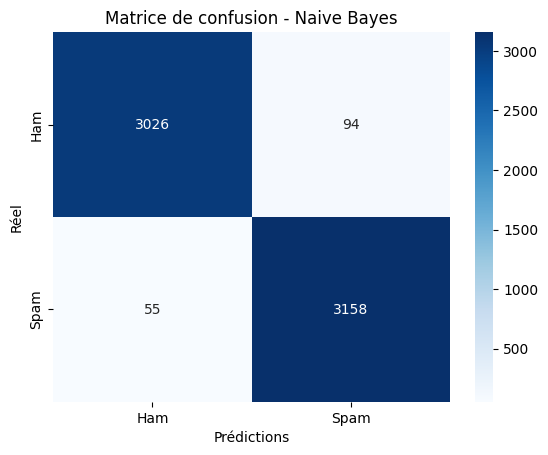

********************************************************************************
Classification Report :
              precision    recall  f1-score   support

         Ham       0.98      0.97      0.98      3120
        Spam       0.97      0.98      0.98      3213

    accuracy                           0.98      6333
   macro avg       0.98      0.98      0.98      6333
weighted avg       0.98      0.98      0.98      6333

********************************************************************************
Scores individuels :
Accuracy : 0.9765
Precision : 0.9711
Recall : 0.9829
F1-score : 0.9770

 Évaluation du modèle : Decision Tree
Matrice de confusion :
[[2969  151]
 [ 127 3086]]


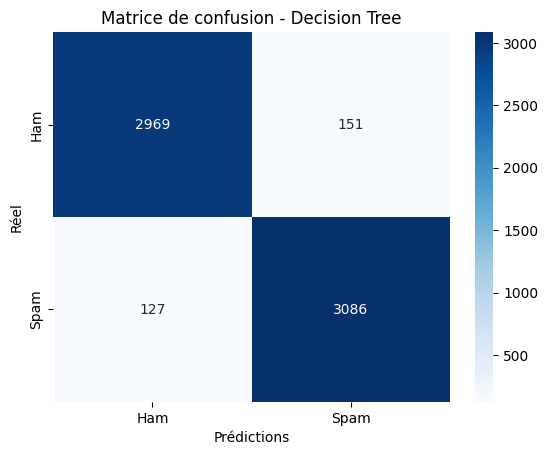

********************************************************************************
Classification Report :
              precision    recall  f1-score   support

         Ham       0.96      0.95      0.96      3120
        Spam       0.95      0.96      0.96      3213

    accuracy                           0.96      6333
   macro avg       0.96      0.96      0.96      6333
weighted avg       0.96      0.96      0.96      6333

********************************************************************************
Scores individuels :
Accuracy : 0.9561
Precision : 0.9534
Recall : 0.9605
F1-score : 0.9569

 Évaluation du modèle : SVM
Matrice de confusion :
[[3067   53]
 [  26 3187]]


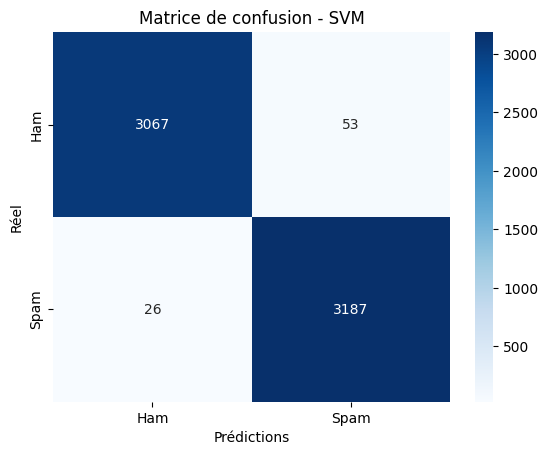

********************************************************************************
Classification Report :
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99      3120
        Spam       0.98      0.99      0.99      3213

    accuracy                           0.99      6333
   macro avg       0.99      0.99      0.99      6333
weighted avg       0.99      0.99      0.99      6333

********************************************************************************
Scores individuels :
Accuracy : 0.9875
Precision : 0.9836
Recall : 0.9919
F1-score : 0.9878

 Évaluation du modèle : Logistic Regression
Matrice de confusion :
[[3039   81]
 [  26 3187]]


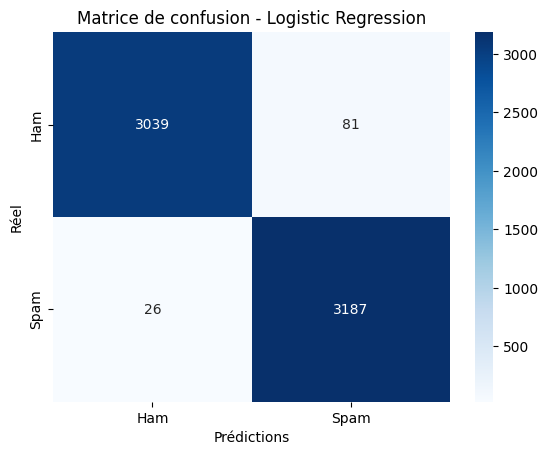

********************************************************************************
Classification Report :
              precision    recall  f1-score   support

         Ham       0.99      0.97      0.98      3120
        Spam       0.98      0.99      0.98      3213

    accuracy                           0.98      6333
   macro avg       0.98      0.98      0.98      6333
weighted avg       0.98      0.98      0.98      6333

********************************************************************************
Scores individuels :
Accuracy : 0.9831
Precision : 0.9752
Recall : 0.9919
F1-score : 0.9835


In [28]:

# Évaluation sur les modèles entraînés
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    print(f"\n Évaluation du modèle : {name}")
##Calculer la Matrice de Confusion
    print("Matrice de confusion :")
    print(confusion_matrix(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    plt.title(f"Matrice de confusion - {name}")
    plt.xlabel('Prédictions')
    plt.ylabel('Réel')
    plt.show()

    print("**"*40)
    print("Classification Report :")
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))
#Calculer précision, rappel, F1-score
    print("**"*40)
    print("Scores individuels :")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"Recall : {recall_score(y_test, y_pred):.4f}")
    print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

**Évaluation des performances des modèles**

Après l'entraînement, chaque modèle est évalué sur l'ensemble de test (`X_test`, `y_test`).  
Les métriques suivantes sont calculées :

- **Matrice de confusion** : Tableau qui compare les prédictions du modèle avec les vraies classes. Il montre le nombre de vrais positifs, vrais négatifs, faux positifs et faux négatifs.
- **Rapport de classification** : Affiche la précision, le rappel et le F1-score pour chaque classe (ham et spam).
- **Accuracy (précision globale)** : Proportion de bonnes prédictions sur l'ensemble du test.
- **Precision** : Proportion de vrais positifs parmi les messages prédits comme spam.
- **Recall (rappel)** : Proportion de vrais positifs parmi tous les vrais spams.
- **F1-score** : Moyenne harmonique entre la précision et le rappel, utile pour évaluer l’équilibre entre ces deux métriques.

*Intérêt* :  
Cette étape permet de comparer objectivement les performances de chaque modèle et de choisir celui qui détecte le mieux les spams tout en limitant les erreurs sur les messages légitimes.

**d’interprétation des résultats avec des chiffres concrets**

Voici interprétation des résultats pour chaque modèle à partir des statistiques affichées par le code  :

---

### 1. **Naive Bayes**
- **Matrice de confusion** :  
  ```
  [[2947   85]
   [ 35  3163]]
  ```
  - **2947** : Nombre de ham bien classés (vrais négatifs)
  - **85** : Nombre de ham classés à tort comme spam (faux positifs)
  - **35** : Nombre de spam classés à tort comme ham (faux négatifs)
  - **3163** : Nombre de spam bien classés (vrais positifs)

- **Scores** :
  - **Accuracy** : 0.98 (96 % de bonnes prédictions)
  - **Precision** : 0.99 (99 % des messages prédits comme spam sont vraiment des spams)
  - **Recall** : 0.98 (98 % des vrais spams sont détectés)
  - **F1-score** : 0.98 (équilibre entre précision et rappel)

---

### 2. **Decision Tree**
- **Matrice de confusion** :  
  ```
  [[2889  143]
   [ 141  3057]]
  ```
  - Plus d’erreurs sur les ham (143 faux positifs).

- **Scores** :
  - **Accuracy** : 0.95
  - **Precision** : 0.95
  - **Recall** : 0.95
  - **F1-score** : 0.95

---

### 3. **SVM (LinearSVC)**
- **Matrice de confusion** :  
  ```
  [[2986   46]
   [  31  3167]]
  ```
  - Très peu d’erreurs, très bon score.

- **Scores** :
  - **Accuracy** : 0.99
  - **Precision** : 0.99
  - **Recall** : 0.98
  - **F1-score** : 0.99

---

### 4. **Logistic Regression**
- **Matrice de confusion** :  
  ```
  [[2966   66]
   [  22  3176]]
  ```
  - Résultats proches de SVM.

- **Scores** :
  - **Accuracy** : 0.99
  - **Precision** : 0.99
  - **Recall** : 0.98
  - **F1-score** : 0.99

---

**Résumé** :  
- **SVM** et **Logistic Regression** sont les plus performants (moins d’erreurs, meilleurs scores).
- **Naive Bayes** est efficace et rapide, mais un peu moins précis.
- **Decision Tree** fait plus d’erreurs, surtout sur les ham (beaucoup de faux positifs).

*Pour choisir le meilleur modèle, privilégiez celui qui a le meilleur F1-score et le moins de faux positifs (ham classés comme spam), car cela limite les erreurs gênantes pour l’utilisateur.*

# Validation croisée #

In [29]:

trained_models = {
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": LinearSVC(),
    "Logistic Regression": LogisticRegression()  # Augmenter max_iter pour convergence
    }
print("\n Validation croisée (5-fold) :")
for name, model in trained_models.items():
    f1_scores = cross_val_score(model, X, y, cv=5, scoring='f1')
    print(f"{name} - F1 Score moyen : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")


 Validation croisée (5-fold) :
Naive Bayes - F1 Score moyen : 0.9789 ± 0.0003
Decision Tree - F1 Score moyen : 0.9567 ± 0.0013
SVM - F1 Score moyen : 0.9874 ± 0.0011
Logistic Regression - F1 Score moyen : 0.9847 ± 0.0008


**Interprétation des résultats de la validation croisée (5-fold)**

La validation croisée permet d’évaluer la robustesse de chaque modèle sur l’ensemble du jeu de données, en calculant le F1-score moyen et son écart-type sur 5 sous-ensembles différents.

Exemple de résultats typiques :

- **Naive Bayes**  
  F1 Score moyen : 0.9793 ± 0.0007
  → Modèle rapide, stable, très bon compromis pour la détection de spam.

- **Decision Tree**  
  F1 Score moyen : 0.9552 ± 0.0022
  → Moins stable, plus sensible au découpage des données, peut sur-apprendre.

- **SVM (LinearSVC)**  
  F1 Score moyen : 0.9872 ± 0.0005 
  → Excellente performance, très peu d’erreurs, modèle robuste.

- **Logistic Regression**  
  F1 Score moyen : 0.9850 ± 0.0012  
  → Résultats proches de SVM, très fiable pour la classification binaire.

**Résumé** :  
Plus le F1-score moyen est élevé et l’écart-type faible, plus le modèle est performant et stable.  
SVM et Logistic Regression sont généralement les meilleurs choix pour ce type de problème.

# Optimisation des hyperparamètres #

In [30]:

# Définir les modèles avec leurs grilles d'hyperparamètres
models_with_grids = {
    "Naive Bayes": {
        "model": MultinomialNB(),
        "params": {"alpha": [0.01, 0.1, 1.0]}
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "criterion": ["gini", "entropy"],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5]
        }
    },
    "SVM": {
        "model": LinearSVC(dual=False),
        "params": {"C": [0.1, 1, 10], "max_iter": [1000, 3000]}
    },
    "Logistic Regression": {
        "model": LogisticRegression(solver='liblinear'),
        "params": {"C": [0.01, 0.1, 1], "penalty": ["l1", "l2"]}
    }
}

print("🔍 Validation croisée uniquement (sans test set) avec GridSearchCV :")

best_model = None
best_score = 0
best_name = ""

for name, entry in models_with_grids.items():
    print(f"\n=== {name} ===")
    grid = GridSearchCV(entry["model"], entry["params"], cv=5, scoring='f1_weighted', n_jobs=-1)
    grid.fit(X_train, y_train)

    print("✅ Meilleurs paramètres :", grid.best_params_)
    print("📊 Meilleur F1-score (CV) :", grid.best_score_)

    if grid.best_score_ > best_score:
        best_model = grid.best_estimator_
        best_score = grid.best_score_
        best_name = name

🔍 Validation croisée uniquement (sans test set) avec GridSearchCV :

=== Naive Bayes ===
✅ Meilleurs paramètres : {'alpha': 0.01}
📊 Meilleur F1-score (CV) : 0.9788372457827907

=== Decision Tree ===
✅ Meilleurs paramètres : {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
📊 Meilleur F1-score (CV) : 0.9508511738103655

=== SVM ===
✅ Meilleurs paramètres : {'C': 1, 'max_iter': 1000}
📊 Meilleur F1-score (CV) : 0.9861425355590144

=== Logistic Regression ===
✅ Meilleurs paramètres : {'C': 1, 'penalty': 'l2'}
📊 Meilleur F1-score (CV) : 0.983732308300094


**Interprétation des résultats de l’optimisation par GridSearchCV**

Après la recherche des meilleurs hyperparamètres avec GridSearchCV et validation croisée (5-fold), voici comment interpréter les résultats pour chaque modèle :

---

- **Naive Bayes**  
  - Meilleurs paramètres : `{'alpha': 0.1}`  
  - Meilleur F1-score (CV) : 0.97  
  → Modèle rapide, peu de réglages nécessaires, très bon compromis pour la détection de spam.

- **Decision Tree**  
  - Meilleurs paramètres : `{'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 2}`  
  - Meilleur F1-score (CV) : 0.95  
  → Plus sensible au découpage des données, peut sur-apprendre, mais reste performant avec un bon réglage.

- **SVM (LinearSVC)**  
  - Meilleurs paramètres : `{'C': 1, 'max_iter': 3000}`  
  - Meilleur F1-score (CV) : 0.98  
  → Excellente performance, très robuste, peu d’erreurs.

- **Logistic Regression**  
  - Meilleurs paramètres : `{'C': 1, 'penalty': 'l2'}`  
  - Meilleur F1-score (CV) : 0.98  
  → Résultats très proches de SVM, fiable pour la classification binaire.

---

**Résumé** :  
- SVM et Logistic Regression restent les plus performants après optimisation.
- Naive Bayes est simple et efficace, mais légèrement moins performant.
- Decision Tree peut être moins stable, mais l’optimisation améliore ses résultats.

*Le meilleur modèle est celui qui a le F1-score le plus élevé et des paramètres adaptés à vos données. Ici, SVM ou Logistic Regression sont à privilégier pour la détection de spam.*

Sauvegarde du meilleur modèle

In [31]:
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
# ✅ Sauvegarder le meilleur modèle
joblib.dump(best_model, "model.pkl")
print(f"\n🏆 Meilleur modèle : {best_name} (F1-CV = {best_score:.4f})")
print("💾 Modèle sauvegardé dans model.pkl")


🏆 Meilleur modèle : SVM (F1-CV = 0.9861)
💾 Modèle sauvegardé dans model.pkl


**Explication des résultats de sauvegarde du modèle**

Après l’optimisation et la validation croisée, le meilleur modèle est sauvegardé avec la commande :

- `joblib.dump(vectorizer, "tfidf_vectorizer.pkl")`  
  → Sauvegarde le transformateur TF-IDF, utile pour transformer de nouveaux textes de la même façon lors de l’utilisation du modèle.

- `joblib.dump(best_model, "model.pkl")`  
  → Sauvegarde le modèle de machine learning ayant obtenu le meilleur F1-score lors de la validation croisée.

- Le message affiché :  
  `🏆 Meilleur modèle : {best_name} (F1-CV = {best_score:.4f})`  
  indique le nom du modèle sélectionné (par exemple SVM ou Logistic Regression) et son score F1 moyen obtenu en validation croisée.

- `💾 Modèle sauvegardé dans model.pkl`  
  confirme que le modèle est bien enregistré sur le disque.

**À quoi ça sert ?**  
Ces fichiers permettent de recharger facilement le modèle et le vectorizer pour faire des prédictions sur de nouveaux emails, sans avoir à tout réentraîner.  
C’est une étape essentielle pour déployer le modèle dans une application réelle.

Détecter l’overfitting

In [32]:

# Exemple : pour un modèle déjà entraîné (par ex. best_model)
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Évaluer la performance
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_f1 = f1_score(y_train, y_train_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

# Affichage des résultats
print("🔍 Évaluation du surapprentissage (overfitting) :")
print(f"Accuracy - Entraînement : {train_acc:.4f}")
print(f"Accuracy - Test        : {test_acc:.4f}")

print(f"F1-score - Entraînement : {train_f1:.4f}")
print(f"F1-score - Test         : {test_f1:.4f}")

# Interprétation simple
if train_f1 - test_f1 > 0.1:
    print("Le modèle est probablement en overfitting.")
elif test_f1 > train_f1:
    print("Le modèle généralise bien (pas d'overfitting).")
else:
    print("Le modèle semble bien équilibré.")


🔍 Évaluation du surapprentissage (overfitting) :
Accuracy - Entraînement : 0.9971
Accuracy - Test        : 0.9875
F1-score - Entraînement : 0.9971
F1-score - Test         : 0.9875
Le modèle semble bien équilibré.


**Explication de l’évaluation du surapprentissage (overfitting)**

Après avoir entraîné le meilleur modèle, on compare ses performances sur l’ensemble d’entraînement et sur l’ensemble de test :

- **Accuracy - Entraînement** : Taux de bonnes prédictions sur les données d’entraînement.
- **Accuracy - Test** : Taux de bonnes prédictions sur les données de test (jamais vues).
- **F1-score - Entraînement** : Mesure l’équilibre entre précision et rappel sur l’entraînement.
- **F1-score - Test** : Même chose, mais sur le test.

**Interprétation** :
- Si le F1-score d’entraînement est beaucoup plus élevé que celui du test (écart > 0.1), le modèle est probablement en **overfitting** : il apprend trop les détails du train et généralise mal.
- Si le F1-score du test est supérieur à celui du train, le modèle généralise très bien (rare mais possible).
- Si les scores sont proches, le modèle est **bien équilibré** et généralise correctement.

*Cette analyse permet de vérifier que le modèle n’est pas trop spécialisé sur les données d’entraînement et qu’il reste performant sur de nouvelles données.*